In [1]:
import numpy as np
import gurobipy as gp
from gurobipy import GRB
from gurobipy import quicksum
import matplotlib.pyplot as plt
import pandas as pd
import datetime
import os

from functions import (plot_DA_week,
                    load_da_market_data,
                    load_fcr_prices,
                    plot_fcr_prices)

## Parameters


In [2]:
#Battery Parameters
battery_capacity = 40 #[MWh]
SOC_min = 1 #[Mwh]
charge_rate_min = 0 #[MW]
discharge_rate_min = 0 #[MW]
charge_rate_max = 10 #[MW]
discharge_rate_max = 10 #[MW]
efficiency = 0.99
self_discharge_rate = 0
initial_SOC = 20 #[MWh]

#Market Parameters:
    #DA:
minimum_bid_DA = 0.1 #[MW]
granularity_DA = 1 #hours

    #FCR:
minimum_bid_FCR = 1 #[MW]
granularity_FCR = 4 #hours
wcs_factor_FCR = [0.36, 0.27, 0.18, 0.9] #[MWh/MW] 

## Data Loading


In [3]:
# Load Day-Ahead Market Prices
da_folder = "data/energy-charts_day_ahead"
years_to_load = [2024]  # available years span 2015-2024

# Load Day-Ahead Market Prices
DA_prices_merged = load_da_market_data(da_folder, years_to_load)
DA_prices_merged["timestamp"] = pd.to_datetime(DA_prices_merged["timestamp"])
DA_prices_merged["timestamp"] = DA_prices_merged["timestamp"] + pd.Timedelta(hours=1) # shift by one hour to fit local time
# Remove timezone information to match FCR timestamps
DA_prices_merged["timestamp"] = DA_prices_merged["timestamp"].dt.tz_localize(None)
DA_prices_merged = DA_prices_merged.sort_values("timestamp").reset_index(drop=True)
#DA_prices_merged["delivery_day"] = DA_prices_merged["timestamp"].dt.floor("D") # create delivery day column

print(f"Loaded {len(DA_prices_merged)} hourly day-ahead price points.")
DA_prices_merged.head()

Loaded 8784 hourly day-ahead price points.


,timestamp,price_eur_mwh
0,2024-01-01 00:00:00,25.97
1,2024-01-01 01:00:00,21.99
2,2024-01-01 02:00:00,14.32
3,2024-01-01 03:00:00,11.37
4,2024-01-01 04:00:00,11.35


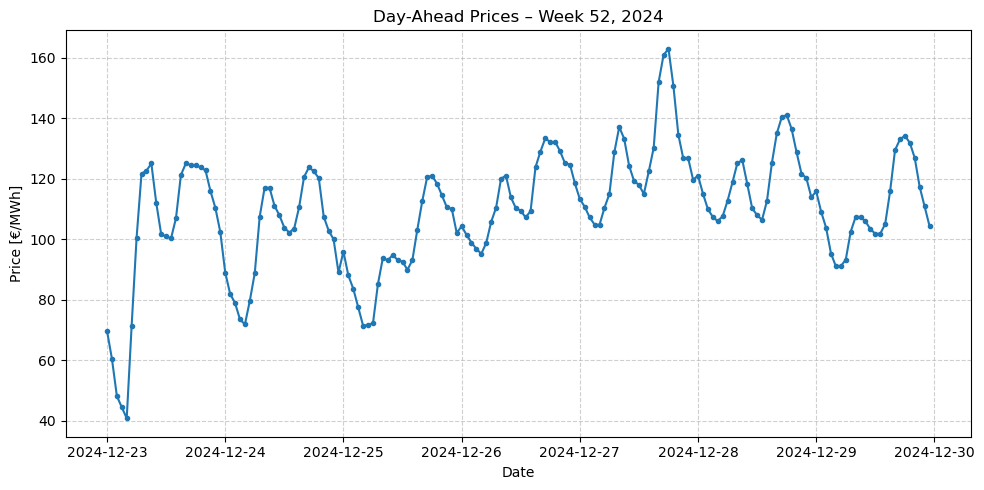

In [4]:
plot_DA_week(DA_prices_merged, year=2024, week=52) #Plot the DA prices for a given week

In [5]:
# =========================
# Load FCR (PRL) prices
# =========================
fcr_folder = "data/Swissgrid_PRL_SRL_TRL"
years_to_load_FCR = [2024]

merged_FCR = load_fcr_prices(fcr_folder, years_to_load_FCR).copy()
# Timestamps in that CSV indicate the hour at which the 4h block starts.
merged_FCR["timestamp"] = pd.to_datetime(merged_FCR["timestamp"])

merged_FCR = merged_FCR.sort_values("timestamp").reset_index(drop=True)
merged_FCR.head()

print(f"Loaded {len(merged_FCR)} FCR blocks.")
merged_FCR.head()

Loaded and merged 1 FCR files (2196 total rows).
Loaded 2196 FCR blocks.


,timestamp,Preis
0,2024-01-01 00:00:00,28.7
1,2024-01-01 04:00:00,26.1
2,2024-01-01 08:00:00,17.2
3,2024-01-01 12:00:00,19.4
4,2024-01-01 16:00:00,18.1


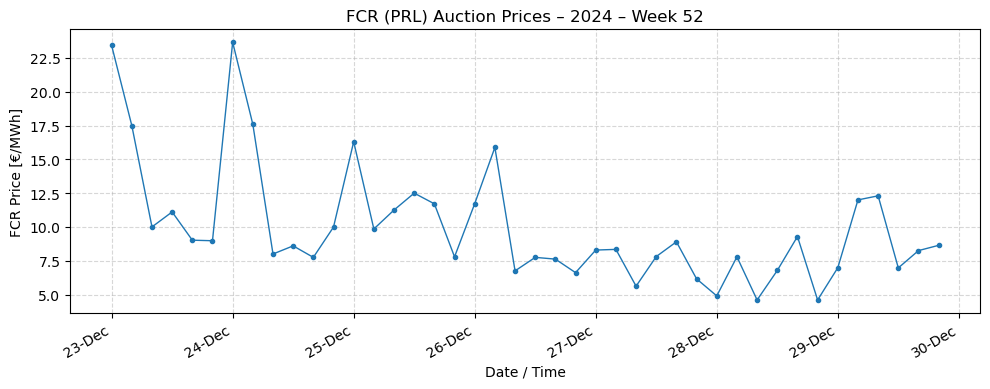

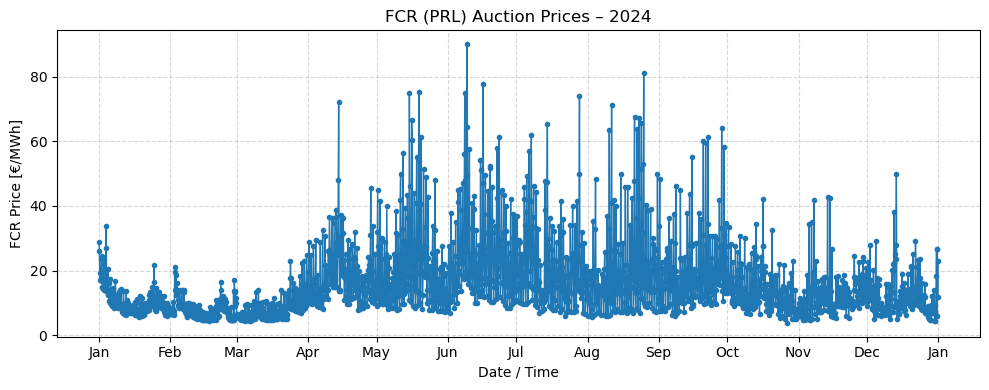

In [6]:
plot_fcr_prices(merged_FCR, year=2024, week=52) #Plot the FCR prices for a given week
plot_fcr_prices(merged_FCR, year=2024) #Plot the FCR prices for the whole year

## Optimal dispatch solver Function for 72h price forecast

In [7]:
# =======================================
# Joint DA + FCR solver for one window
# =======================================
def solve_da_fcr(
    da_block,
    fcr_prices_block,
    initial_soc,
    *,
    granularity_DA=1,
    granularity_FCR=4,
    battery_capacity=40.0,
    soc_min=1.0,
    charge_rate_bounds=(0.0, 10.0),
    discharge_rate_bounds=(0, 10.0),
    efficiency=0.99,
    self_discharge_rate=0.0,
    minimum_bid_FCR=1.0,
    wcs_factor_FCR=(0.36, 0.27, 0.18, 0.90),
    time_limit_seconds=300,
    gurobi_output=False,
    terminal_soc_target=None,
):
    """
    Combined Day-Ahead + FCR optimization for one 72h horizon,
    using the simple FCR indexing style (4h blocks).
    """

    # === 1. Prepare DA prices and time grid
    da_block = da_block.sort_values("timestamp").reset_index(drop=True)
    clearing_price_DA = da_block["price_eur_mwh"].to_numpy(dtype=float)
    n_hours = len(clearing_price_DA)

    FCR_horizon = range(int(n_hours / granularity_FCR))  # number of 4h blocks

    clearing_price_FCR = fcr_prices_block["Preis"].to_numpy(dtype=float)
    assert len(clearing_price_FCR) == len(FCR_horizon), (
        f"FCR price length {len(clearing_price_FCR)} "
        f"≠ number of 4h blocks {len(FCR_horizon)}"
    )

    # === 2. Create optimization model
    MMO = gp.Model("DA_FCR_receding_horizon")
    MMO.Params.OutputFlag = 1 if gurobi_output else 0
    MMO.Params.TimeLimit = time_limit_seconds

    charge_lb, charge_ub = charge_rate_bounds
    discharge_lb, discharge_ub = discharge_rate_bounds

    #Decision variables
    Charge = MMO.addVars(n_hours, vtype=GRB.CONTINUOUS, lb=charge_lb, ub=charge_ub, name="Charge")
    Discharge = MMO.addVars(n_hours, vtype=GRB.CONTINUOUS, lb=discharge_lb, ub=discharge_ub, name="Discharge")
    Charging_Indicator = MMO.addVars(n_hours, vtype=GRB.BINARY, name="Charging_Indicator")
    SOC = MMO.addVars(n_hours + 1, vtype=GRB.CONTINUOUS, lb=soc_min, ub=battery_capacity, name="SOC")

    FCR_Participation = MMO.addVars(FCR_horizon, vtype=GRB.BINARY, name="FCR_Participation")
    FCR_Volume = MMO.addVars(FCR_horizon, vtype=GRB.CONTINUOUS, lb=0.0, ub=charge_ub, name="FCR_Volume")


    # === 3. Battery SOC balance
    MMO.addConstr(SOC[0] == initial_soc)
    for t in range(n_hours):
        MMO.addConstr(SOC[t + 1] == (1 - self_discharge_rate) * SOC[t] + granularity_DA * (efficiency * Charge[t] - (1 / efficiency) * Discharge[t]))

    if terminal_soc_target is not None: # enforce terminal SOC for last time step!
        MMO.addConstr(SOC[n_hours] == terminal_soc_target)

    # === 4. Prevent simultaneous charge & discharge
    for t in range(n_hours):
        MMO.addGenConstrIndicator(Charging_Indicator[t], True, Discharge[t] == 0)
        MMO.addGenConstrIndicator(Charging_Indicator[t], False, Charge[t] == 0)

    # === 5. FCR constraints 
    for t in FCR_horizon:
        # Minimum bid if participating
        MMO.addConstr(FCR_Participation[t] * minimum_bid_FCR <= FCR_Volume[t])
        MMO.addConstr(FCR_Volume[t] <= charge_ub * FCR_Participation[t])

        for j in range(granularity_FCR):
            h = granularity_FCR * t + j

            # SOC headroom
            MMO.addConstr(SOC[h] >= soc_min + FCR_Volume[t] * wcs_factor_FCR[j])
            MMO.addConstr(SOC[h] <= battery_capacity - FCR_Volume[t] * wcs_factor_FCR[j])

            # Power headroom
            MMO.addConstr(Discharge[h] + FCR_Volume[t] <= discharge_ub)
            MMO.addConstr(Charge[h] + FCR_Volume[t] <= charge_ub)

        # === 7. Limit daily cycling over 3 days ===
    max_daily_cycles = 1
    avg_agg_FCR_discharge = 0.136  # MWh/MW of FCR Volume capacity per 4 hours
    n_days = n_hours // 24  # number of complete 24h days in the horizon
    for d in range(n_days):
        MMO.addConstr(
            quicksum(Discharge[24//granularity_DA * d + t] for t in range(24//granularity_DA))
            + quicksum(avg_agg_FCR_discharge * FCR_Volume[24//granularity_FCR * d + t] for t in range(24//granularity_FCR))
            <= max_daily_cycles * battery_capacity
        )



    # === 6. Objective (DA + FCR revenue)
    DA_term = quicksum(clearing_price_DA[t] * (Discharge[t] - Charge[t]) * granularity_DA for t in range(n_hours))
    FCR_term = quicksum(FCR_Volume[t] * clearing_price_FCR[t] * granularity_FCR for t in FCR_horizon)

    MMO.setObjective(DA_term + FCR_term, GRB.MAXIMIZE)
    MMO.optimize()

    # === 7. Extract solution
    schedule = {
        "charge": np.array([Charge[t].X for t in range(n_hours)]),
        "discharge": np.array([Discharge[t].X for t in range(n_hours)]),
        "soc": np.array([SOC[t].X for t in range(n_hours + 1)]),
        "fcr_volume": np.array([FCR_Volume[t].X for t in FCR_horizon]),
    }

    return {
        "objective_value": MMO.ObjVal,
        "schedule": schedule,
        "terminal_soc": schedule["soc"][-1],
    }



## Receding Horizon Loop

In [12]:
# =====================================================
# RECEDING HORIZON LOOP (72h look-ahead, 24h apply)
# =====================================================

look_ahead_hours = 72 # 3 days, each optimization looks at 72 hours of price 
apply_hours = 24
state_soc = initial_SOC

timestamps = DA_prices_merged["timestamp"]
start_time = timestamps.min()
end_time = timestamps.max()

hourly_rows = []
daily_rows = []

current_time = start_time  # initialize the moving window start time

while current_time + pd.Timedelta(hours=apply_hours) <= end_time: ##loop 24h at a time until we reach the end of the data

    # Select DA window (72h)
    horizon_end = current_time + pd.Timedelta(hours=look_ahead_hours)
    da_block = DA_prices_merged[
        (DA_prices_merged["timestamp"] >= current_time)
        & (DA_prices_merged["timestamp"] < horizon_end)
    ].copy() #select 72h block for DA prices, will return 72 1h blocks prices

    if len(da_block) == 0:
        print(f"Skipping {current_time.date()} — no DA data available.")
        current_time += pd.Timedelta(hours=apply_hours)
        continue

    # Select corresponding FCR window (same 72h)
    fcr_prices_block = merged_FCR[
        (merged_FCR["timestamp"] >= current_time)
        & (merged_FCR["timestamp"] < horizon_end)
    ].copy() #select 72h block for FCR prices, will return 18 4h blocks prices

    # Terminal SOC for last horizon
    target_soc = initial_SOC if horizon_end >= end_time else None

    # Solve DA+FCR optimization for the next 72h
    result = solve_da_fcr(
        da_block,
        fcr_prices_block,
        state_soc,
        granularity_DA=granularity_DA,
        granularity_FCR=granularity_FCR,
        battery_capacity=battery_capacity,
        soc_min=SOC_min,
        charge_rate_bounds=(charge_rate_min, charge_rate_max),
        discharge_rate_bounds=(discharge_rate_min, discharge_rate_max),
        efficiency=efficiency,
        self_discharge_rate=self_discharge_rate,
        minimum_bid_FCR=minimum_bid_FCR,
        wcs_factor_FCR=wcs_factor_FCR,
        time_limit_seconds=300,
        gurobi_output=False,
        terminal_soc_target=target_soc,
    )

    # Extract optimal schedule for the next 72h
    schedule = result["schedule"] #dictionary with keys: "charge", "discharge", "soc", "fcr_volume"
    soc_profile = schedule["soc"]
    charge = schedule["charge"]
    discharge = schedule["discharge"]
    fcr_volume = schedule["fcr_volume"]

    n_apply = int(apply_hours / granularity_DA) #number of hours to apply (24h)
    block_apply = da_block.iloc[:n_apply].copy()

    # --- record hourly dispatch, but only for the first 24h ---
    for t in range(n_apply):
        ts = block_apply["timestamp"].iloc[t]
        hourly_rows.append({
            "timestamp": ts,
            "charge_mw": charge[t],
            "discharge_mw": discharge[t],
            "soc_mwh": soc_profile[t + 1],
            "fcr_reserve_mw": fcr_volume[t // granularity_FCR],
            "price_eur_mwh": block_apply["price_eur_mwh"].iloc[t],
        })

    # --- compute realized profits ---
    #DA revenue 
    net_export = discharge[:n_apply] - charge[:n_apply]
    da_profit = float(np.dot(block_apply["price_eur_mwh"].to_numpy(), net_export) * granularity_DA)

    # FCR revenue: 4h blocks starting within the first 24h
    n_fcr_apply = int(apply_hours / granularity_FCR) #number of 4h blocks to apply (6 blocks)
    fcr_prices_apply = fcr_prices_block.head(n_fcr_apply)#only the first n_fcr_apply=6 rows
    fcr_revenue = float(np.dot(schedule["fcr_volume"][:n_fcr_apply],fcr_prices_apply["Preis"].to_numpy())*granularity_FCR)

    total_profit = da_profit + fcr_revenue

    daily_rows.append({
        "run_time": current_time,
        "profit_model": result["objective_value"],
        "profit_realized": total_profit,
        "da_profit": da_profit,
        "fcr_revenue": fcr_revenue,
        "terminal_soc": soc_profile[n_apply],
    })

    # 6 Update SOC and move horizon forward
    state_soc = soc_profile[n_apply]
    current_time += pd.Timedelta(hours=apply_hours)

# =====================================================
# RESULTS
# =====================================================
profit_df = pd.DataFrame(daily_rows)
dispatch_df = pd.DataFrame(hourly_rows)
annual_profit = profit_df["profit_realized"].sum()

print(f"Simulated {len(profit_df)} receding-horizon steps.")
print(f"Total DA + FCR profit: {annual_profit:,.2f} €")


Simulated 365 receding-horizon steps.
Total DA + FCR profit: 1,560,754.56 €


## Extracting Results

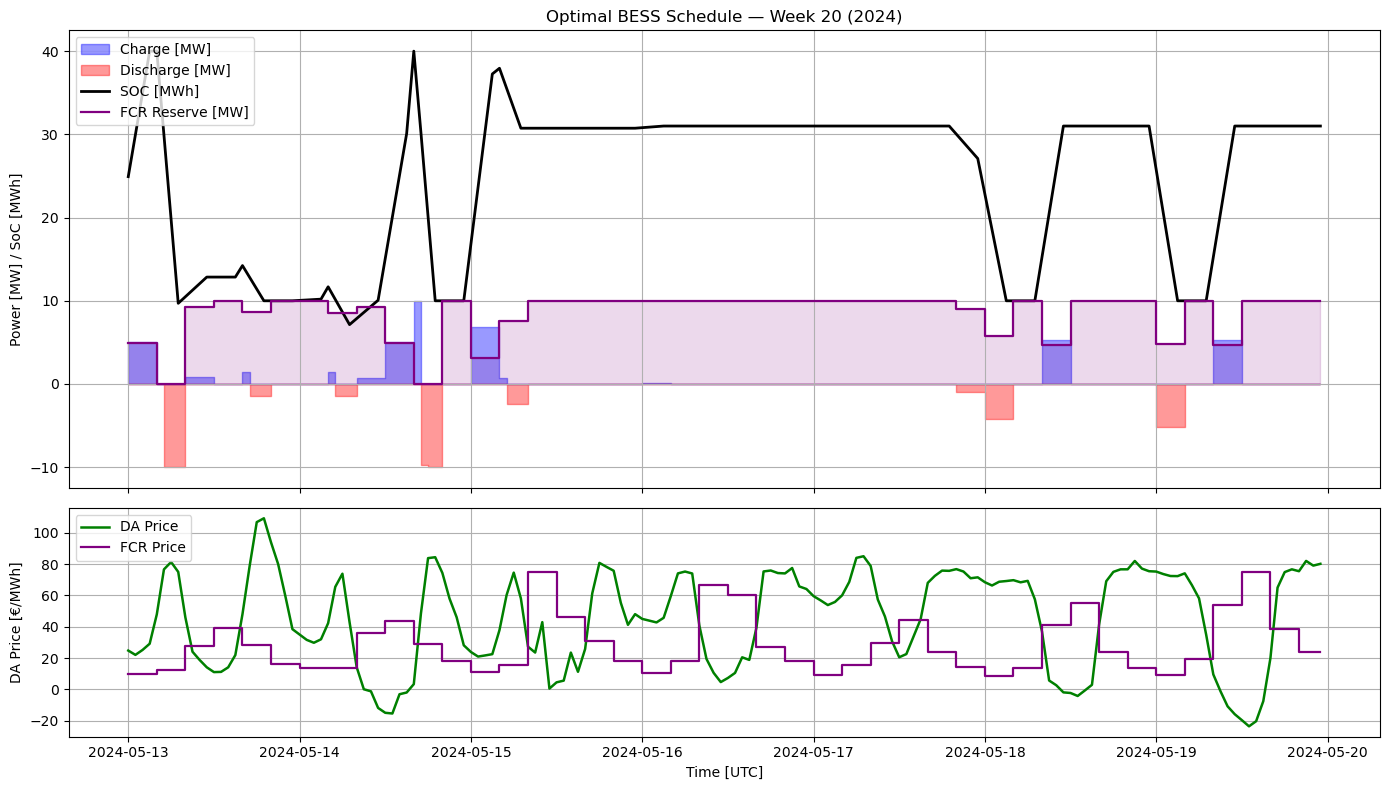

In [14]:
# =====================================================
# WEEKLY VISUALIZATION — only using existing variables
# =====================================================

week_number = 20  # choose week to visualize
hours_per_week = 24 * 7
start_idx = (week_number - 1) * hours_per_week
end_idx = start_idx + hours_per_week

# --- Extract hourly data for that week ---
time_week = dispatch_df["timestamp"].iloc[start_idx:end_idx]
Charge_week = dispatch_df["charge_mw"].iloc[start_idx:end_idx].to_numpy()
Discharge_week = dispatch_df["discharge_mw"].iloc[start_idx:end_idx].to_numpy()
SOC_week = dispatch_df["soc_mwh"].iloc[start_idx:end_idx].to_numpy()
Price_week = dispatch_df["price_eur_mwh"].iloc[start_idx:end_idx].to_numpy()
FCR_reserve_week = dispatch_df["fcr_reserve_mw"].iloc[start_idx:end_idx].to_numpy()


# --- Expand FCR prices (4h → 1h) for plotting ---
FCR_price_hourly = np.repeat(merged_FCR["Preis"].to_numpy(), granularity_FCR)
FCR_price_hourly = FCR_price_hourly[: len(dispatch_df)]  # align lengths
FCR_price_week = FCR_price_hourly[start_idx:end_idx]

# --- Prepare a placeholder FCR reserve signal (visual only) ---
# Here we simply replicate the structure: nonzero every 4h where prices exist
# → purely for plotting, not optimization results.
FCR_week = dispatch_df["fcr_reserve_mw"].iloc[start_idx:end_idx].to_numpy()


# =====================================================
# PLOTTING
# =====================================================
fig, axs = plt.subplots(2, 1, figsize=(14, 8), sharex=True, gridspec_kw={"height_ratios": [2, 1]})

# --- TOP: Battery operation ---
axs[0].fill_between(time_week, 0, Charge_week, step="post", alpha=0.4, color="blue", label="Charge [MW]")
axs[0].fill_between(time_week, 0, -Discharge_week, step="post", alpha=0.4, color="red", label="Discharge [MW]")
axs[0].fill_between(time_week, 0, FCR_reserve_week, step="post", alpha=0.15, color="purple")
axs[0].plot(time_week, SOC_week, color="black", linewidth=2, label="SOC [MWh]")
axs[0].step(time_week, FCR_week, where="post", color="purple", linewidth=1.6, label="FCR Reserve [MW]")

axs[0].set_ylabel("Power [MW] / SoC [MWh]")
axs[0].grid(True)
axs[0].legend(loc="upper left")
axs[0].set_title(f"Optimal BESS Schedule — Week {week_number} ({time_week.dt.year.iloc[0]})")

# --- BOTTOM: Prices ---
axs[1].plot(time_week, Price_week, color="green", linewidth=1.8, label="DA Price")
axs[1].step(time_week, FCR_price_week, where="post", color="purple", linewidth=1.6, label="FCR Price")
axs[1].set_ylabel("DA Price [€/MWh]")
axs[1].set_xlabel("Time [UTC]")
axs[1].grid(True)
axs[1].legend(loc="upper left")

plt.tight_layout()
plt.show()
